In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import os
import numpy as np
import pylab as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import pairwise_distances
from modules import MDSTorusProjector, apsp_distance_matrix, plot_embedding_with_torus_edges
import umap
import cmocean
from modules.initialization import (find_fundamental_torus_directions, torus_init_from_eigenpairs,
                                    rect_torus_init_from_spectral, _torus_geom_from_result)
from modules.metrics import rect_torus_stress
from data.utils import get_path

In [89]:
import modules
from matplotlib import font_manager

modules_dir = os.path.dirname(modules.__file__)
torus_mds_dir = os.path.dirname(modules_dir)

# register the bundled Arial faces so the style's "font.sans-serif: Arial" resolves
# instead of silently falling back. addfont works per session, no font cache rebuild.
for ttf in font_manager.findSystemFonts(fontpaths=[os.path.join(torus_mds_dir, "arial_font")]):
    font_manager.fontManager.addfont(ttf)

plt.style.use(os.path.join(modules_dir, "style.mplstyle"))

print("Arial registered:", "Arial" in {f.name for f in font_manager.fontManager.ttflist})

Arial registered: True


In [90]:
data_path = os.path.join(get_path(), "3figures")
pca = np.load(os.path.join(data_path, "yoda_bulldog_pca50.npy"))
phases = np.load(os.path.join(data_path, "phases.npy"))
print(pca.shape, phases.shape)
cmap = cmocean.cm.phase

(8100, 50) (8100, 2)


In [91]:
# helpers
def circ_align(u, theta):
    """|circular alignment| between a torus coordinate u in [0, 1) and an angle theta in [0, 2pi),
    invariant to global offset and orientation. Output in [0, 1]"""
    zu = np.exp(2j * np.pi * np.asarray(u))
    zt = np.exp(1j * np.asarray(theta))
    return max(abs(np.mean(zu * np.conj(zt))), abs(np.mean(zu * zt)))


def mean_std(values, fmt=".3f"):
    """format an iterable of numbers as 'mean ± std'"""
    v = np.asarray(list(values), dtype=float)
    return f"{v.mean():{fmt}} ± {v.std():{fmt}}"


def report_recovery(Xs, phases, label):
    """circ_align of each embedding axis against both ground-truth phases, as mean ± std
    over runs. Xs is a single (N, 2) embedding, an iterable of them, or a {seed: X} dict."""
    if isinstance(Xs, dict):
        Xs = list(Xs.values())
    elif np.ndim(Xs) == 2:
        Xs = [Xs]
    else:
        Xs = list(Xs)
    for ax_i in range(2):
        yoda = [circ_align(X[:, ax_i], phases[:, 0]) for X in Xs]
        bull = [circ_align(X[:, ax_i], phases[:, 1]) for X in Xs]
        print(f"{label} (n={len(Xs)}), axis {ax_i}: circ_align yoda {mean_std(yoda)}, "
              f"bulldog {mean_std(bull)}")

## Full data: geodesic distances, spectral init, MDS with init


In [92]:
# compute kNN graph representation
k = 15
A_geo = kneighbors_graph(pca, n_neighbors=k, mode='distance', include_self=False)
A_geo = A_geo.maximum(A_geo.T)  # symmetrize, weights = euclidean edge lengths
G_geo = nx.from_scipy_sparse_array(A_geo)

D_geo, _ = apsp_distance_matrix(G_geo)
Dn = D_geo / D_geo.max()   # normalized distances (max 1), what the MDS runs train on

assert not np.isinf(D_geo).any(), "kNN graph is disconnected, increase k"
print(D_geo.shape, f"max geodesic: {D_geo.max():.0f}")

(8100, 8100) max geodesic: 60200


In [93]:
seeds = [0, 1, 2]

# note: find_fundamental_torus_directions takes no seed argument, so the spectral layout is
# deterministic given D. it is still recomputed once per seed to keep the three pipelines
# symmetric, so its spread reported below is expected to be ~0.
specs, inits_spectral, geoms_spectral = {}, {}, {}
for seed in seeds:
    s = find_fundamental_torus_directions(D_geo)
    coords, r0, r1 = rect_torus_init_from_spectral(s)   # phases + diameter-scaled side lengths
    specs[seed], inits_spectral[seed], geoms_spectral[seed] = s, coords, (r0, r1)
    print(f"seed {seed}: estimated aspect ratio {s['aspect_ratio']:.2f}, r0={r0:.3f}, r1={r1:.3f}")

# seed 0 is the run visualized below
spec, init_spectral = specs[0], inits_spectral[0]
fund = spec["fundamental_directions"]
report_recovery(inits_spectral, phases, "spectral init")

seed 0: estimated aspect ratio 1.19, r0=1.530, r1=1.288
seed 1: estimated aspect ratio 1.19, r0=1.530, r1=1.288
seed 2: estimated aspect ratio 1.19, r0=1.530, r1=1.288
spectral init (n=3), axis 0: circ_align yoda 0.980 ± 0.000, bulldog 0.055 ± 0.000
spectral init (n=3), axis 1: circ_align yoda 0.036 ± 0.000, bulldog 0.959 ± 0.000


Text(0.5, 0.98, 'Spectral layout full dataset (seed 0)')

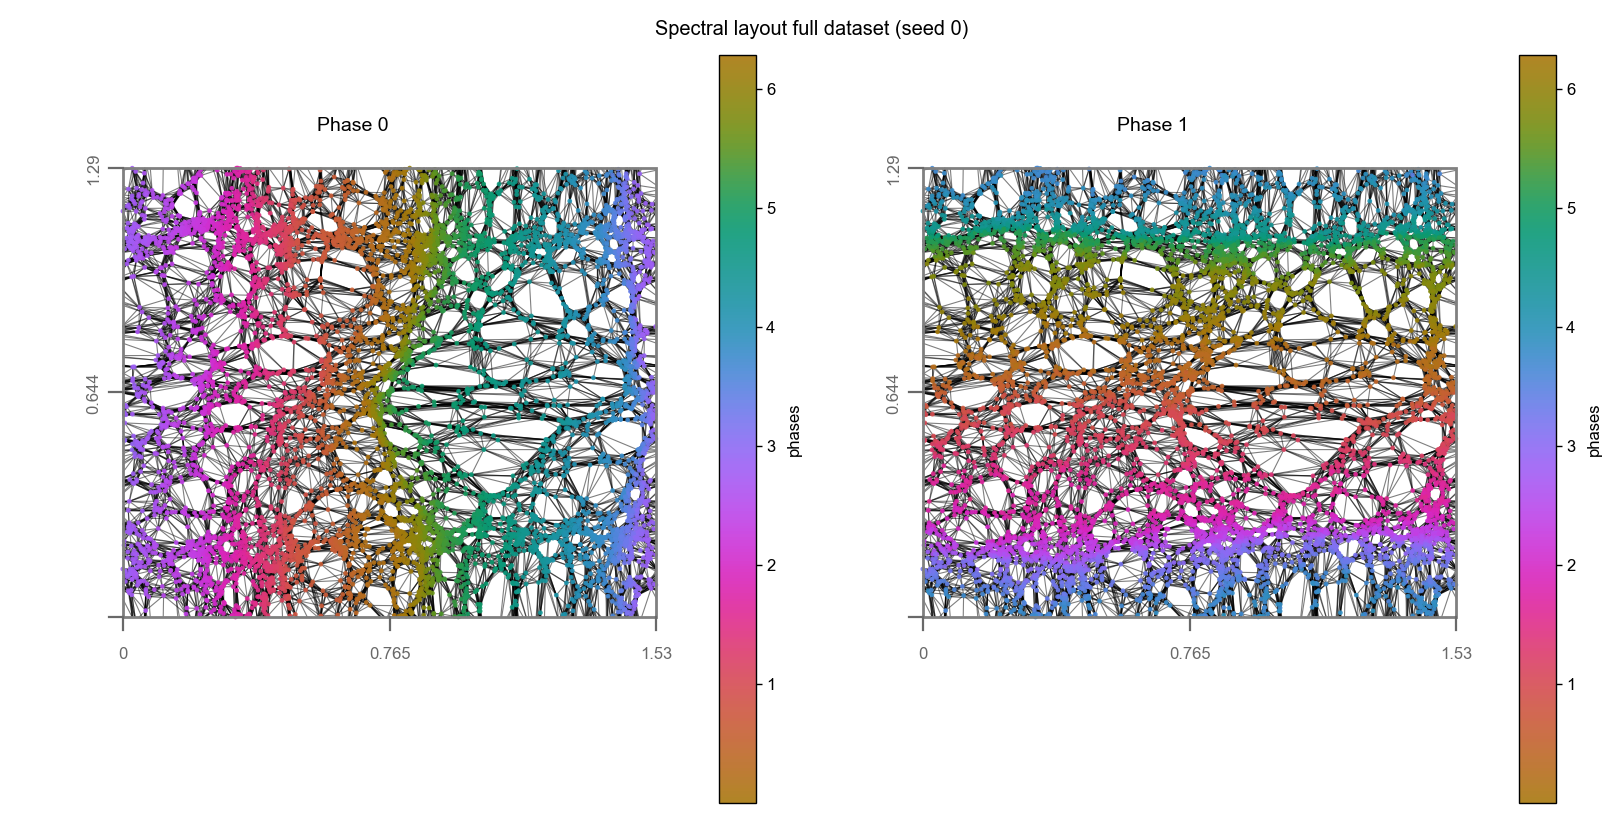

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)


colors = [cmap(phase / ( 2*np.pi)) for phase in phases.T]

for i in range(2):
    plot_embedding_with_torus_edges(
        G=G_geo, torus=_torus_geom_from_result(spec), ax=ax[i], s=2, colors=phases[:, i], cmap=cmap, edge_alpha=0.5)
    plt.colorbar(ax[i].collections[-1], ax=ax[i], label="phases")
    ax[i].set_title(f"Phase {i}")
fig.suptitle("Spectral layout full dataset (seed 0)")


SGD from spectral init (n=3), axis 0: circ_align yoda 0.988 ± 0.000, bulldog 0.021 ± 0.000
SGD from spectral init (n=3), axis 1: circ_align yoda 0.002 ± 0.001, bulldog 0.879 ± 0.001


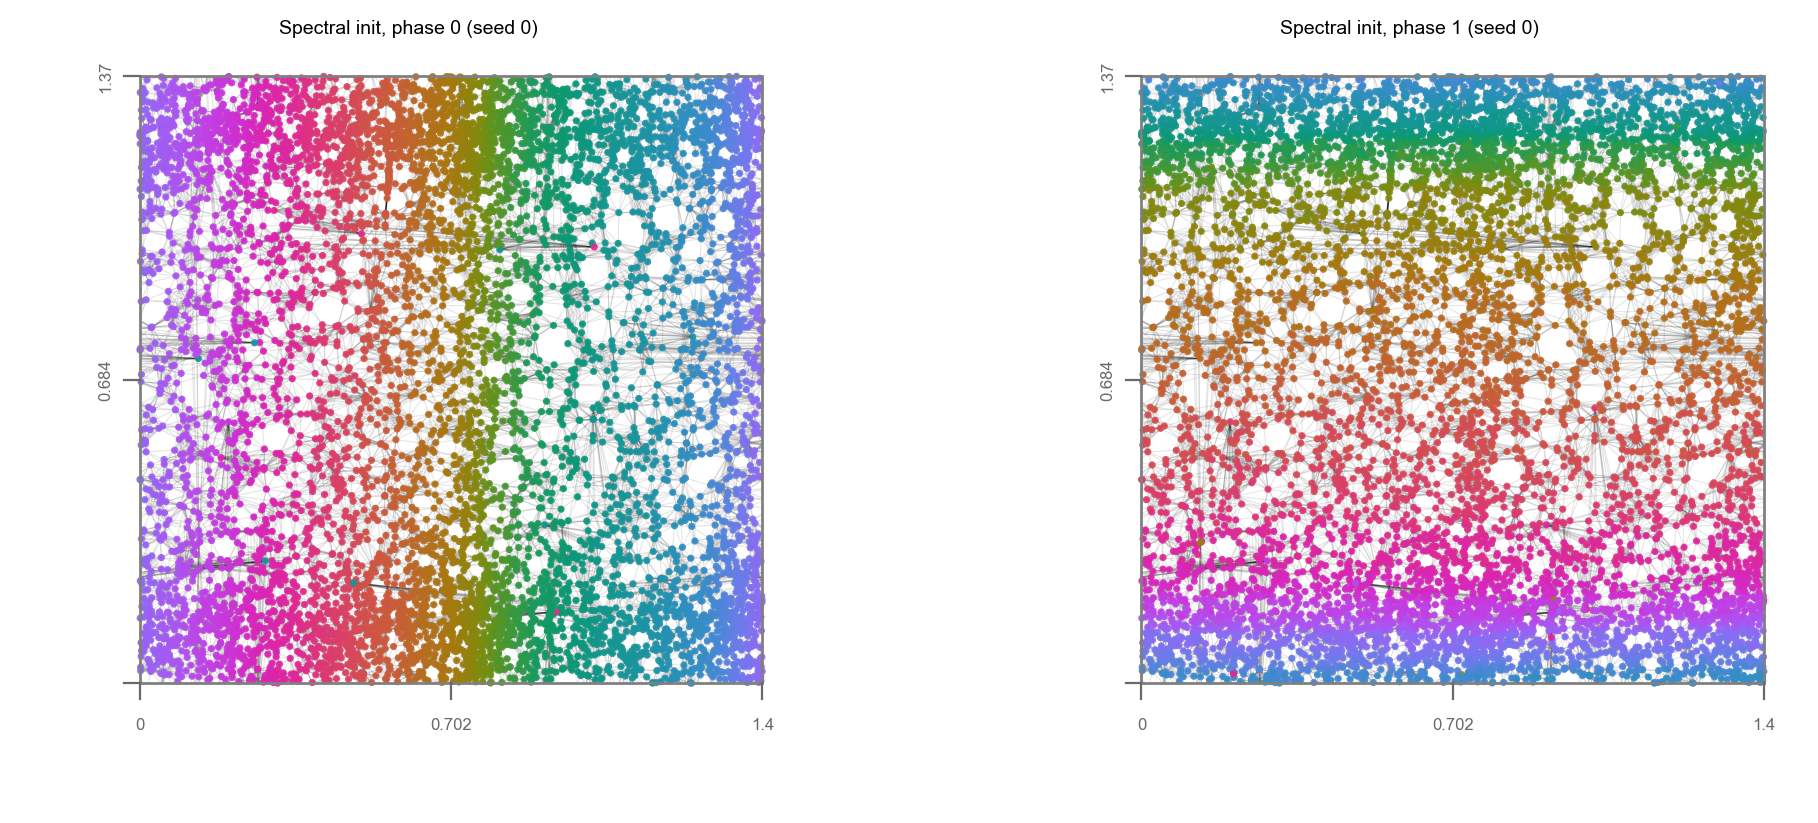

In [95]:
# MDS with spectral layout init, one run per seed (seed drives the SGD pair sampling)
projs_spec, Xs_spec = {}, {}
for seed in seeds:
    proj = MDSTorusProjector()
    Xs_spec[seed] = proj.fit_transform(Dn, learn_mode='rectangular', init=specs[seed], seed=seed)
    projs_spec[seed] = proj

report_recovery(Xs_spec, phases, "SGD from spectral init")
proj_spec, X_spec = projs_spec[0], Xs_spec[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_spec, G=G_geo, torus=proj_spec, colors=colors[i], ax=ax)
    ax.set_title(f"Spectral init, phase {i} (seed 0)")
plt.show()

SGD from random init (n=3), axis 0: circ_align yoda 0.525 ± 0.148, bulldog 0.205 ± 0.076
SGD from random init (n=3), axis 1: circ_align yoda 0.485 ± 0.056, bulldog 0.263 ± 0.031


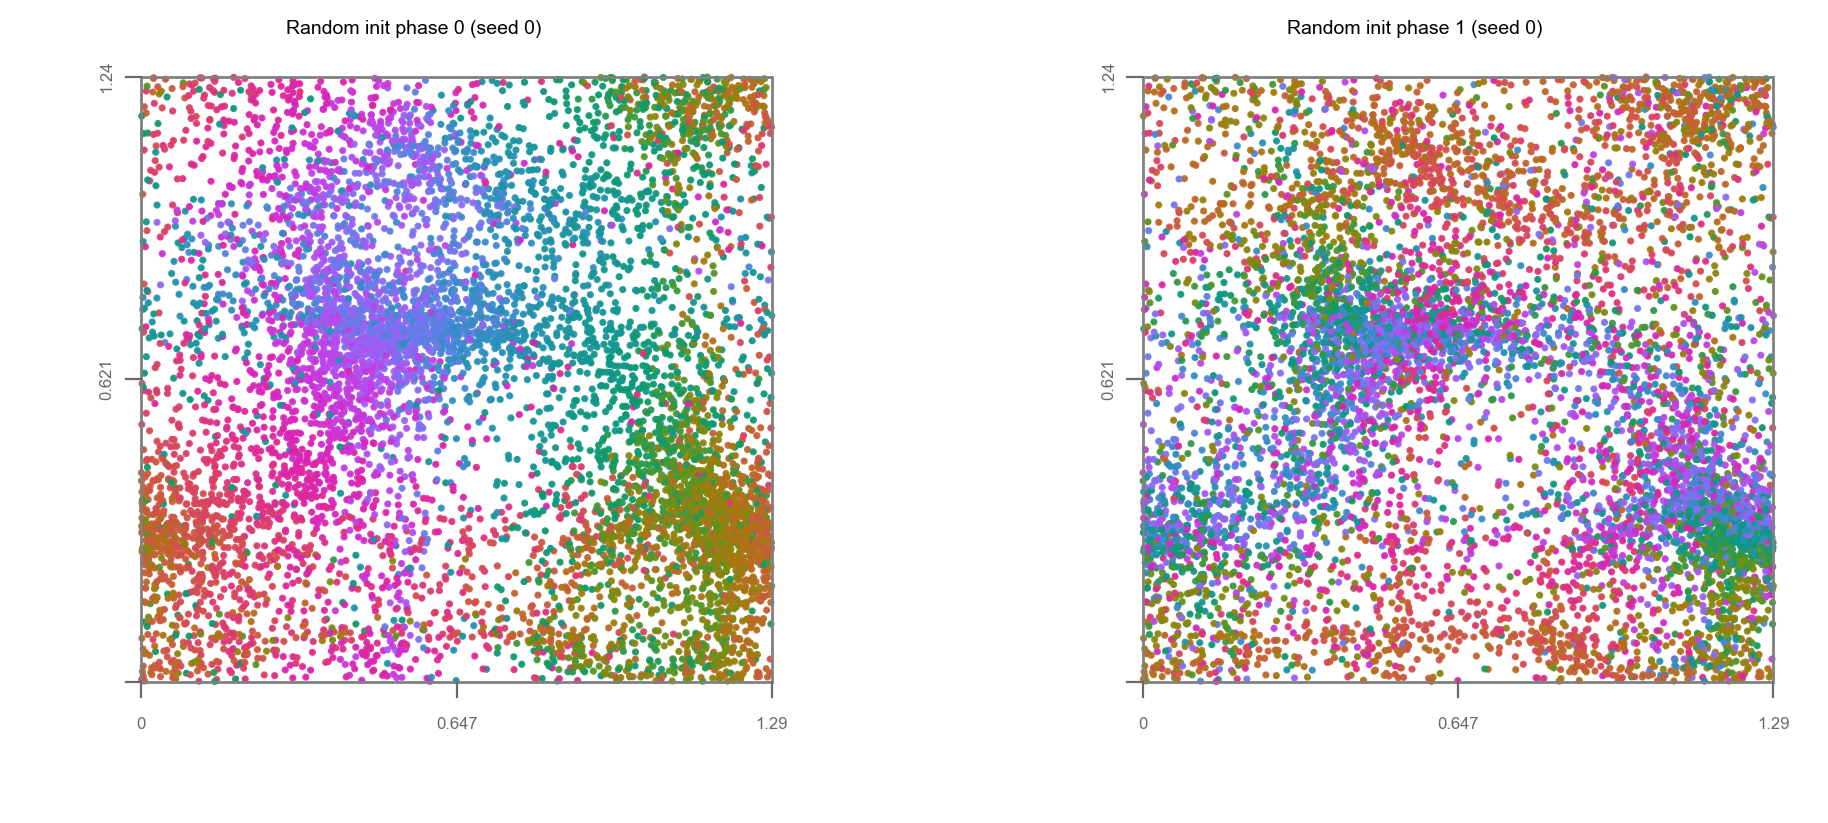

In [96]:
# baseline: SGD from a random init (no spectral/GT warm start), same setup otherwise --> does not work well
# here the seed drives both the random start and the pair sampling
projs_rand, Xs_rand = {}, {}
for seed in seeds:
    proj = MDSTorusProjector()
    Xs_rand[seed] = proj.fit_transform(Dn, learn_mode='rectangular',
                                       r0_init=1.0, r1_init=1.0, seed=seed)   # init=None -> random start
    projs_rand[seed] = proj

# note: a random start can also swap which axis picks up which figurine, so a large std
# here reflects that inconsistency on top of the run-to-run quality spread
report_recovery(Xs_rand, phases, "SGD from random init")
proj_rand, X_rand = projs_rand[0], Xs_rand[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_rand, G=None, torus=proj_rand, colors=colors[i], ax=ax)
    ax.set_title(f"Random init phase {i} (seed 0)")
plt.show()

In [97]:
# normalized stress per embedding (numba-accelerated, rectangular torus), mean +- std over seeds.
s_init, s_spec, s_rand = [], [], []
for seed in seeds:
    r0_s, r1_s = geoms_spectral[seed]
    s_init.append(rect_torus_stress(inits_spectral[seed], Dn, r0=r0_s, r1=r1_s, alpha=None)[0])
    p = projs_spec[seed]
    s_spec.append(rect_torus_stress(Xs_spec[seed], Dn, r0=p.r0_, r1=p.r1_, alpha=None)[0])
    p = projs_rand[seed]
    s_rand.append(rect_torus_stress(Xs_rand[seed], Dn, r0=p.r0_, r1=p.r1_, alpha=None)[0])

print(f"over {len(seeds)} seeds {seeds}:")
print(f"spectral layout (spectral geom): stress = {mean_std(s_init, '.4f')}")
print(f"SGD from spectral init (fitted): stress = {mean_std(s_spec, '.4f')}")
print(f"SGD from random init (fitted):   stress = {mean_std(s_rand, '.4f')}")

over 3 seeds [0, 1, 2]:
spectral layout (spectral geom): stress = 0.1340 ± 0.0000
SGD from spectral init (fitted): stress = 0.0401 ± 0.0025
SGD from random init (fitted):   stress = 0.3515 ± 0.0172


In [27]:
from PIL import Image

img = np.array(Image.open(os.path.join(data_path, "data", "s1_100001.jpg")).convert("RGB"))

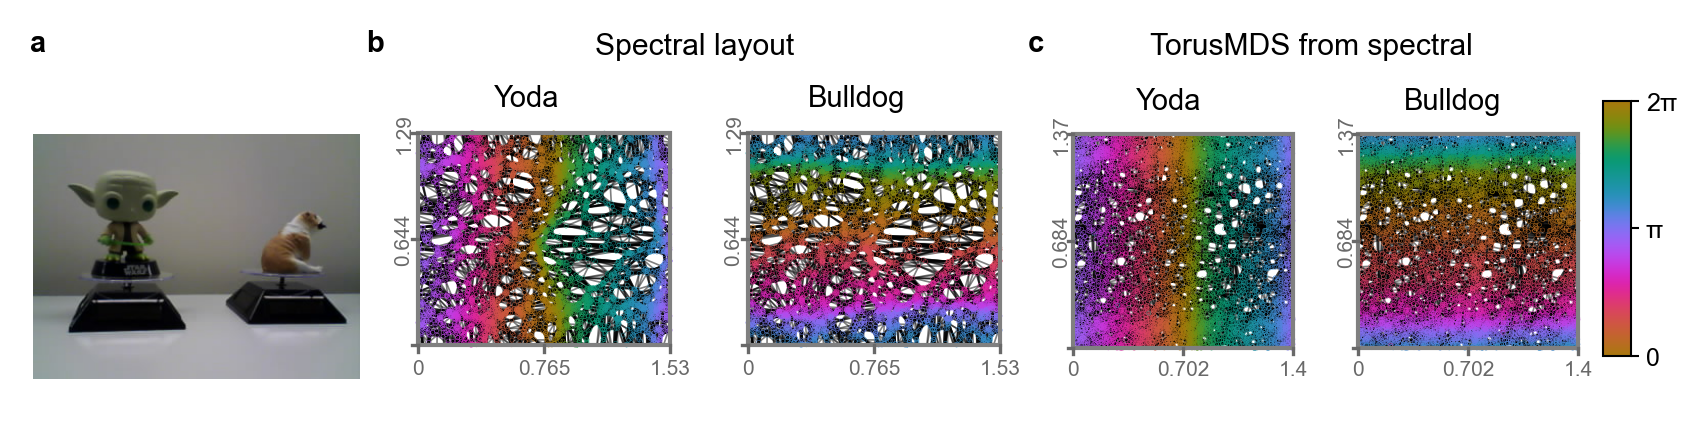

In [98]:
# one subfigure per group, so the group title is centred over that group's panels and
# the panel letters land at a single height (all subfigures span the full figure height,
# unlike the axes, whose boxes differ). widths follow the drawn aspect of the panels so
# constrained_layout letterboxes none of them. one extra subfigure holds the colorbar.
figurines = ["Yoda", "Bulldog"]
s = 0.05
geom_spec = _torus_geom_from_result(spec)

# (letter, group title, [(panel label, torus, X), ...])
groups = [
    ("a", " ", []),
    ("b", "Spectral layout", [(f, geom_spec, None) for f in figurines]),
    ("c", "TorusMDS from spectral", [(f, proj_spec, X_spec) for f in figurines]),
]


def panel_aspect(torus):
    """width / height of a torus panel as drawn (tick margins are equal on both axes)"""
    return 1.0 if torus is None else torus.r0_ / torus.r1_


group_w = [img.shape[1] / img.shape[0] * 0.9] + \
          [sum(panel_aspect(t) for _, t, _ in g[2]) for g in groups[1:]] + \
          [0.29]                  # colorbar column: the bar plus room for its tick labels

fig = plt.figure(figsize=(5.5, 1.4), dpi=300, layout="constrained")

fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.0)
subfigs = fig.subfigures(1, len(group_w), width_ratios=group_w, wspace=0.01)

for (letter, group_title, panels), sfig in zip(groups, subfigs):
    sfig.suptitle(group_title)      # " " on the photo reserves the same line as the others
    sfig.text(0.0, 1.0, letter, ha="left", va="top", fontweight="bold", fontsize=7)

    if not panels:                  # the photo
        a = sfig.subplots()
        a.imshow(img)
        a.axis('off')
        a.set_title(" ")            # reserve the panel-title line too, so the tops align
        continue

    axs = sfig.subplots(1, len(panels),
                        width_ratios=[panel_aspect(t) for _, t, _ in panels])
    for a, (figurine, torus, X_panel) in zip(np.atleast_1d(axs), panels):
        plot_embedding_with_torus_edges(
            G=G_geo,
            torus=torus,
            X=X_panel,
            ax=a,
            s=s,
            colors=phases[:, figurines.index(figurine)],
            cmap=cmap,
            vmin=0,               # pin the range so one colorbar describes every panel
            vmax=2 * np.pi,
            edge_alpha=0.5,
            n_ticks=3,            # 5 ticks at fontsize 8 collide on ~1 inch wide panels
            tick_fontsize=5,      # deliberately below the 6pt body text of style.mplstyle
            rasterized=True)      # ~65k edges per panel: keep them out of the vector layer
        a.set_title(figurine)

# shared phase colorbar in its own axes on the right, with the same header reservation
# as the panel groups so the bar lines up with the panel row. plain unicode pi rather
# than mathtext, so the labels use Arial and not the dejavusans mathtext font.
cb_lift = 0.3                      # empty bottom row: raises the bar off the figure floor
sfig_cb = subfigs[-1]
sfig_cb.suptitle(" ")
cax = sfig_cb.add_subplot(sfig_cb.add_gridspec(2, 1, height_ratios=[1, cb_lift])[0])
cax.set_title(" ")
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0, 2 * np.pi), cmap=cmap),
                    cax=cax, ticks=[0, np.pi, 2 * np.pi])
cbar.ax.set_yticklabels(["0", "π", "2π"])

# rasterized artists take their resolution from the savefig dpi, not from figure.dpi
fig.savefig(os.path.join(data_path, "fig_YB.pdf"), dpi=400)
